<a href="https://colab.research.google.com/github/mrunalkavade/Deep-Learning-Based-COVID-19-Classification-Using-Chest-Radiography-Images/blob/main/CNN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive to Access Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define Dataset Path

In [ ]:
dataset_path = "/content/drive/MyDrive/DL/archive.zip"

Extract the Dataset

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/DL/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Verify Dataset Extracted Properly

In [ ]:
import os
os.listdir('/content/dataset')

['COVID-19_Radiography_Dataset']

Check Extracted Dataset Directory

In [ ]:
os.listdir('/content/dataset/COVID-19_Radiography_Dataset')

['Viral Pneumonia',
 'COVID.metadata.xlsx',
 'Viral Pneumonia.metadata.xlsx',
 'Lung_Opacity.metadata.xlsx',
 'Normal',
 'COVID',
 'Normal.metadata.xlsx',
 'Lung_Opacity',
 'README.md.txt']

In [ ]:
dataset_path = "/content/dataset/COVID-19_Radiography_Dataset"

In [ ]:
import os

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

for cls in classes:
    path = os.path.join(dataset_path, cls, "images")
    print(cls, ":", len(os.listdir(path)))

COVID : 3616
Normal : 10192
Lung_Opacity : 6012
Viral Pneumonia : 1345


In [ ]:
import os

base_dir = "/content/covid_split"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

Split Data (70 / 15 / 15)

In [ ]:
import shutil, random

dataset_path = "/content/dataset/COVID-19_Radiography_Dataset"

for cls in classes:
    img_path = os.path.join(dataset_path, cls, "images")
    images = os.listdir(img_path)
    random.shuffle(images)

    total = len(images)
    train_split = int(0.7 * total)
    val_split   = int(0.85 * total)

    for i, img in enumerate(images):
        src = os.path.join(img_path, img)

        if i < train_split:
            dst = os.path.join(train_dir, cls, img)
        elif i < val_split:
            dst = os.path.join(val_dir, cls, img)
        else:
            dst = os.path.join(test_dir, cls, img)

        shutil.copy(src, dst)

Verify Split

In [ ]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} DATA:")
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        print(cls, ":", len(os.listdir(path)))


TRAIN DATA:
COVID : 2531
Normal : 7134
Lung_Opacity : 4208
Viral Pneumonia : 941

VAL DATA:
COVID : 542
Normal : 1529
Lung_Opacity : 902
Viral Pneumonia : 202

TEST DATA:
COVID : 543
Normal : 1529
Lung_Opacity : 902
Viral Pneumonia : 202


Data Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

Load Data

In [ ]:
train_data = train_gen.flow_from_directory(
    "/content/covid_split/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    "/content/covid_split/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    "/content/covid_split/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 14814 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.


Build Model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 4
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Training & Validation Accuracy

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 241s 502ms/step - accuracy: 0.5907 - loss: 0.9595 - val_accuracy: 0.6907 - val_loss: 0.7549
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 213s 460ms/step - accuracy: 0.6792 - loss: 0.7890 - val_accuracy: 0.7228 - val_loss: 0.6466
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 215s 465ms/step - accuracy: 0.7149 - loss: 0.7117 - val_accuracy: 0.7682 - val_loss: 0.5805
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 213s 461ms/step - accuracy: 0.7332 - loss: 0.6644 - val_accuracy: 0.7739 - val_loss: 0.5631
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 214s 462ms/step - accuracy: 0.7547 - loss: 0.6288 - val_accuracy: 0.7984 - val_loss: 0.5184
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 216s 466ms/step - accuracy: 0.7675 - loss: 0.6000 - val_accuracy: 0.8072 - val_loss: 0.4941
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 216s 467ms/step - accuracy: 0.7769 - loss: 0.5735 - val_accuracy: 0.8318 - val_loss: 0.4554
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 217s 469ms/step - accuracy: 0.7929 -

Extract values

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

Print final values

In [ ]:
print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.8099770545959473
Final Validation Accuracy: 0.8585826754570007


Plot Training vs Validation Accuracy

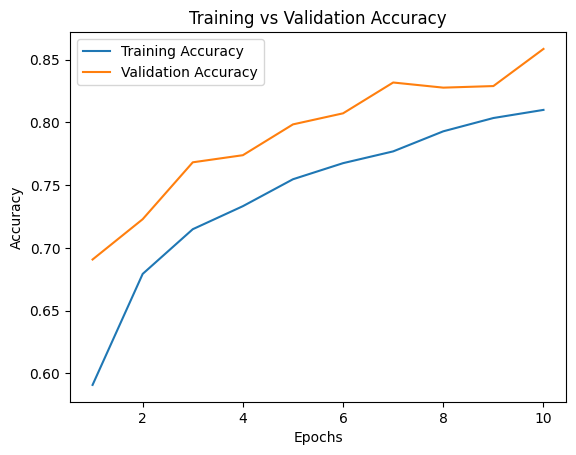

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Epochs
epochs = range(1, len(train_acc) + 1)

# Plot
plt.figure()
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

# Labels and Title
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Legend
plt.legend()

# Show graph
plt.show()

Plot loss

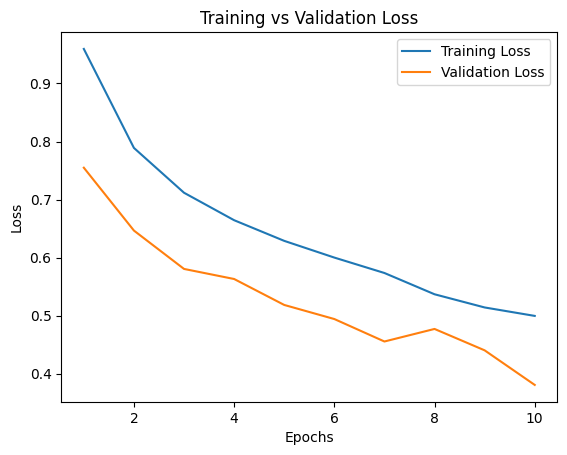

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

TEST accuracy

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.8624 - loss: 0.3649
Test Accuracy: 0.86240553855896


In [ ]:
import numpy as np

predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step


In [ ]:
true_classes = test_data.classes

In [ ]:
class_labels = list(test_data.class_indices.keys())
print(class_labels)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[ 417   35   90    1]
 [  14  701  186    1]
 [  12   55 1459    3]
 [   3    2   35  162]]


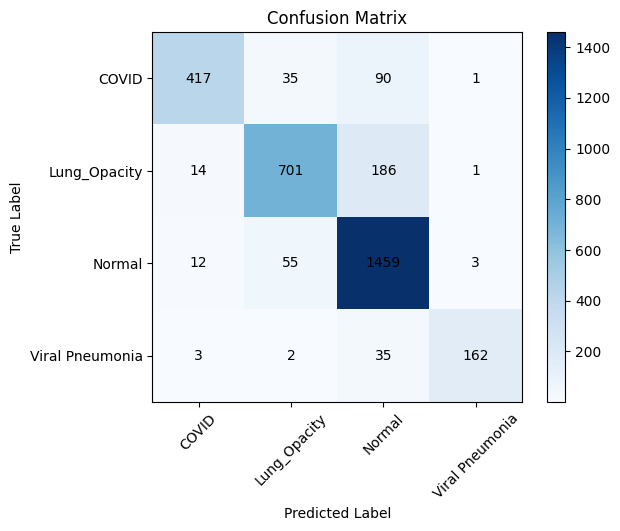

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Train for more epochs

In [ ]:
epochs = 15 or 20

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 216s 467ms/step - accuracy: 0.8209 - loss: 0.4749 - val_accuracy: 0.8721 - val_loss: 0.3577
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 215s 464ms/step - accuracy: 0.8246 - loss: 0.4664 - val_accuracy: 0.8699 - val_loss: 0.3783
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 214s 462ms/step - accuracy: 0.8335 - loss: 0.4478 - val_accuracy: 0.8699 - val_loss: 0.3533
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 214s 462ms/step - accuracy: 0.8366 - loss: 0.4401 - val_accuracy: 0.8765 - val_loss: 0.3431
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 212s 459ms/step - accuracy: 0.8459 - loss: 0.4195 - val_accuracy: 0.8702 - val_loss: 0.3692
Epoch 6/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 214s 461ms/step - accuracy: 0.8482 - loss: 0.4133 - val_accuracy: 0.8365 - val_loss: 0.4764
Epoch 7/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 215s 465ms/step - accuracy: 0.8408 - loss: 0.4257 - val_accuracy: 0.8743 - val_loss: 0.3381
Epoch 8/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 212s 458ms/step - accuracy: 0.8550 -

Final Training & Validation Accuracy

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

Final Training Accuracy: 0.8099770545959473
Final Validation Accuracy: 0.8585826754570007


Accuracy Graph

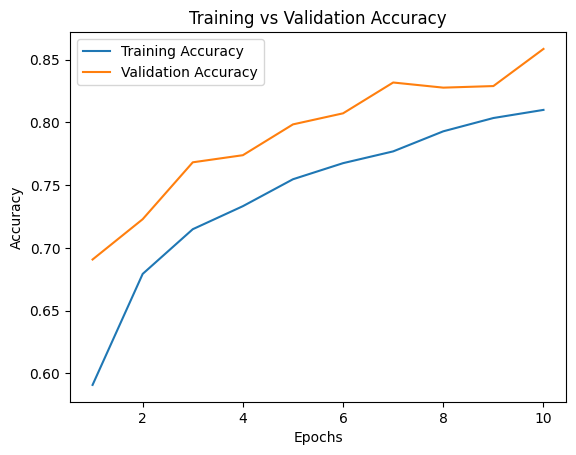

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure()
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Plot Loss Graph

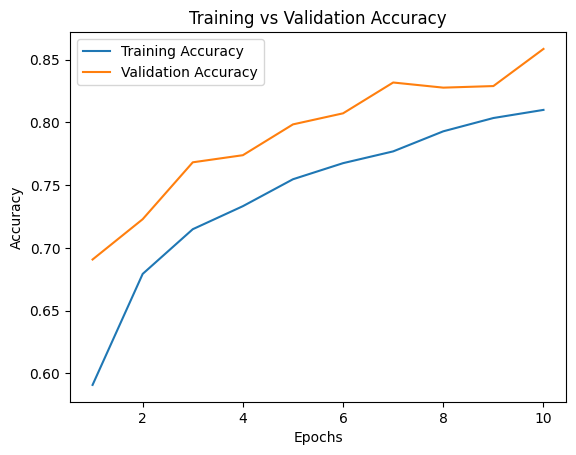

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure()
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Evaluate on Test Data

In [ ]:
loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.8854 - loss: 0.3138
Test Accuracy: 0.8853904008865356


100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step


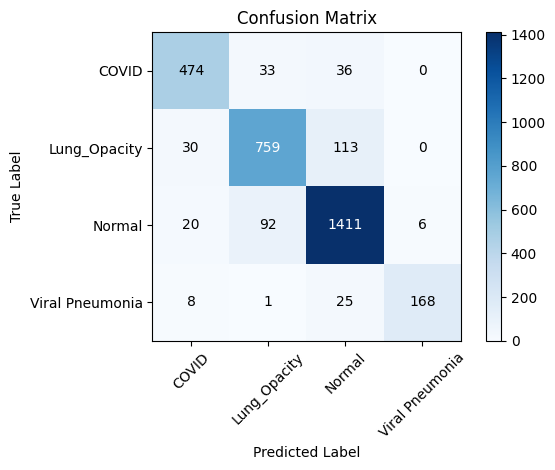

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_data.classes

# Class labels
class_labels = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure()
plt.imshow(cm, cmap='Blues')  # professional color

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

# Add values inside boxes
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar()
plt.tight_layout()
plt.show()